In [1]:
#!/usr/bin/env python3
#/Users/anushree/Desktop/SledLab/data analysis/preprocessing_eyedata.ipynb
# -*- coding: utf-8 -*-
"""
Created on Tue Apr 29 21:20 2025

@author: anushreeganesh
"""

'\nCreated on Tue Apr 29 21:20 2025\n\n@author: anushreeganesh\n'

In [2]:
#Loading the data
import scipy.io
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

mat = scipy.io.loadmat('HW2_EncodingModels.mat')

In [3]:
mat.keys() 

dict_keys(['__header__', '__version__', '__globals__', 'RA_Spikes1', 'RA_Spikes2', 'SA1_Spikes1', 'SA1_Spikes2', 'Stim1', 'Stim2'])

In [4]:
#Q1: given the ramping stimuli: Stim1, RA_Spikes1,SA1Spikes_1:

A_min = 5
A_max = 20
F_min = 0
F_max = 1000
R_max = 1000
stim1 = mat['Stim1']
stim2 = mat['Stim2']
RA1 = mat['RA_Spikes1']
RA2 = mat['RA_Spikes2']
SA1 = mat['SA1_Spikes1']
SA2 = mat['SA1_Spikes2']

s_lows = []
s_highs = []
A_anm_all, F_anm_all = [], []
A_fnm_all, F_fnm_all = [], []
A_hnm1_all, F_hnm1_all = [], []
A_hnm2_all, F_hnm2_all = [], []
#amplitude encoding model:
def ANM(s, s_low, s_high):
    A = np.zeros(s.shape)
    for i in range(len(s)):
        if s[i] < s_low:
            A[i] = 0
        elif s[i] > s_high:
            A[i] = A_max
        else:
            A[i] = A_min + (A_max - A_min) * ((s[i] - s_low)/(s_high - s_low))
    #pulse freq fixed at 50Hz; call it here or outside?
    #F = 50
    return A

#frequecny encoding model:

bin_width = 10
def FNM(RA1, SA1,f, bin_width =10, F_min = 0, F_max = 1000, R_max = 1000):
    RA = RA1[:, : , f]
    SA1 = SA1[:, : ,f]
    spikes = np.vstack([RA, SA1]) # for sum of each of the 100 mechanoreceptors at each timepoint
    n , time = spikes.shape
    bins = time//bin_width
    R = np.zeros(bins)
    for b in range(bins):
        start = b * bin_width
        end = (b+1) * bin_width
        total_spikes = np.sum(spikes[:,start:end])
        R[b] = total_spikes / (n * 0.01)
    F = np.zeros_like(R)
    for i in range(len(R)):
        if R[i] <=0:
            F[i] = F_min
        elif R[i]>= R_max:
            F[i] = F_max
        else:
            F[i] = F_min + (F_max - F_min) * R[i]/R_max
    F_matrix = np.repeat(F, bin_width)[:time]

    A = (A_max - A_min) /2
    A_matrix = np.ones_like(F_matrix) * A
    return F_matrix, A_matrix

def HNM1(s,s_low, s_high, RA1, SA1, f):
    A = ANM(s, s_low, s_high)
    F, _ = FNM(RA1, SA1, f)
    return A, F

def HNM2( RA1, SA1, f, A_min = 5, A_max = 20):
    RA_f = RA1[:,:,f]
    SA1_f = SA1[:,:,f]
    spikes = np.vstack([RA_f, SA1_f])
    N_act = np.sum(spikes>0, axis =0)
    A = A_min +(A_max - A_min) * (N_act /(spikes.shape[0]))
    F, _ = FNM(RA1, SA1, f)

    return A, F

#finding s_n, s_15 and s_75:
for f in range(3):
    s = stim1[f, :]
    #print(f'force is {f}',s)
    s_max = np.max(s)
    #print(f'max = {s_max}')
    s_low = 0.15 * s_max
    s_high = 0.75 * s_max

    s_lows.append(s_low)
    s_highs.append(s_high)
    #print(f's_lows = {s_lows} , s_highs = {s_highs}')
    #anm
    A_anm = ANM(s, s_low, s_high)
    A_anm_all.append(A_anm)
    F_anm_all.append(np.ones_like(A_anm) * 50)

    #fnm
    F_fnm, A_fnm = FNM(RA1, SA1, f)
    A_fnm_all.append(A_fnm)
    F_fnm_all.append(F_fnm)

    #hnm1
    
    A_hnm1, F_hnm1 = HNM1(s, s_low, s_high, RA1, SA1, f)
    A_hnm1_all.append(A_hnm1)
    F_hnm1_all.append(F_hnm1)

    #hnm2
    A_hnm2, F_hnm2 = HNM2(RA1, SA1, f)
    A_hnm2_all.append(A_hnm2)
    F_hnm2_all.append(F_hnm2)


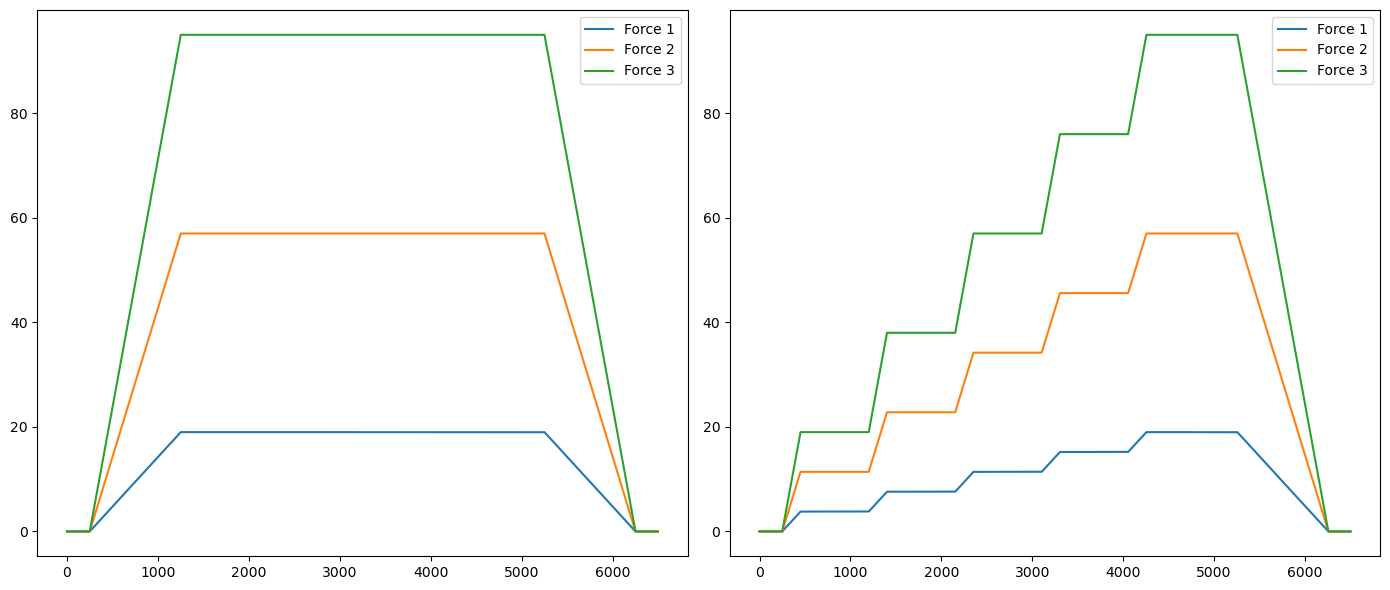

In [5]:
time = np.arange(stim1.shape[1])

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(time, stim1[0], label="Force 1")
plt.plot(time, stim1[1], label="Force 2")
plt.plot(time, stim1[2], label="Force 3")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time, stim2[0], label="Force 1")
plt.plot(time, stim2[1], label="Force 2")
plt.plot(time, stim2[2], label="Force 3")
plt.legend()

plt.tight_layout()
plt.show()

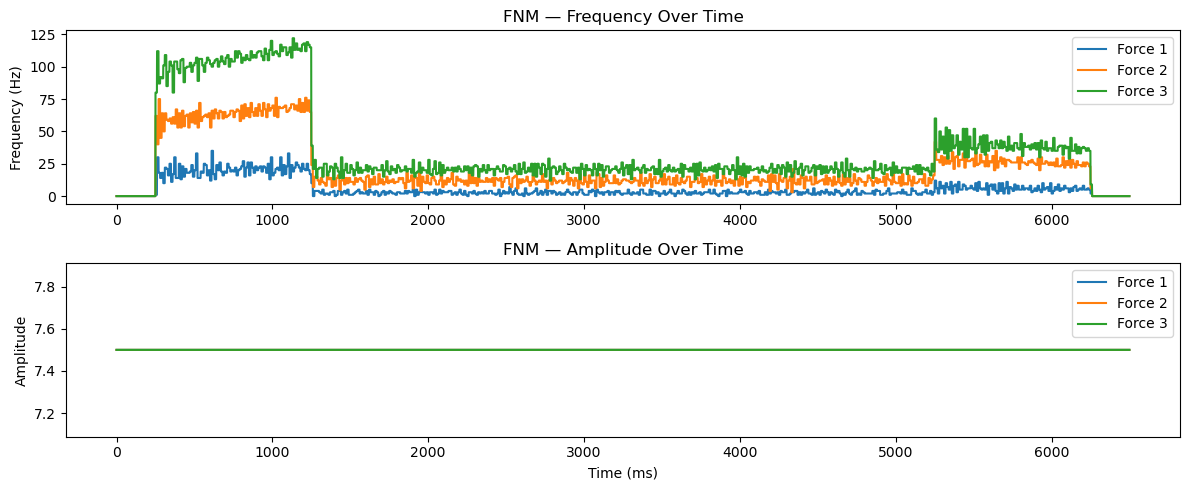

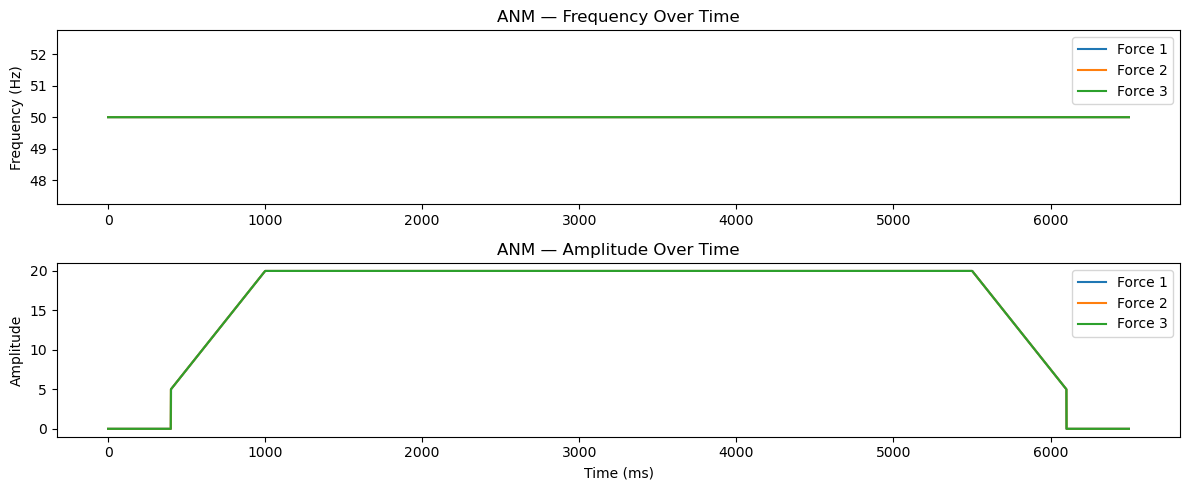

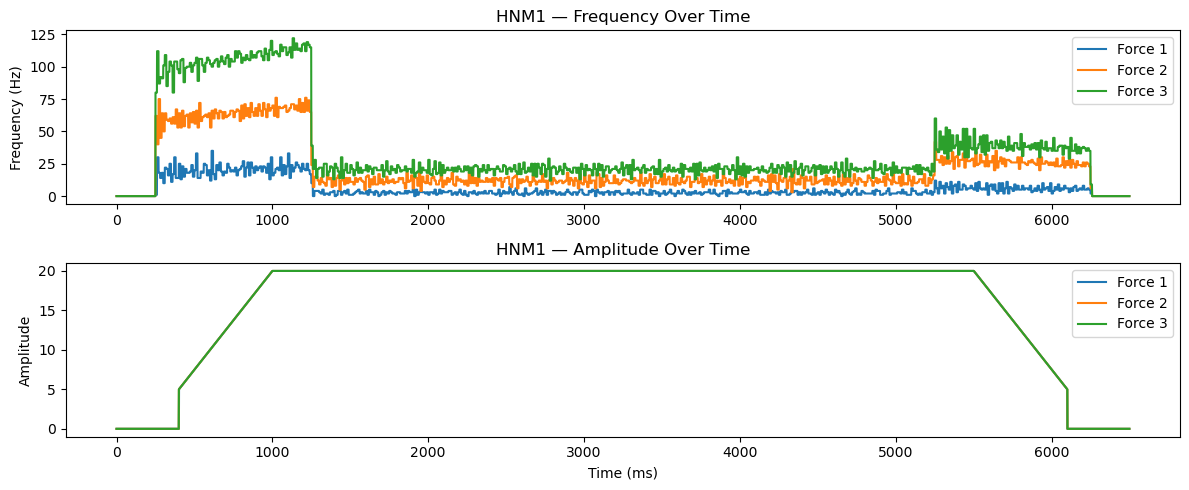

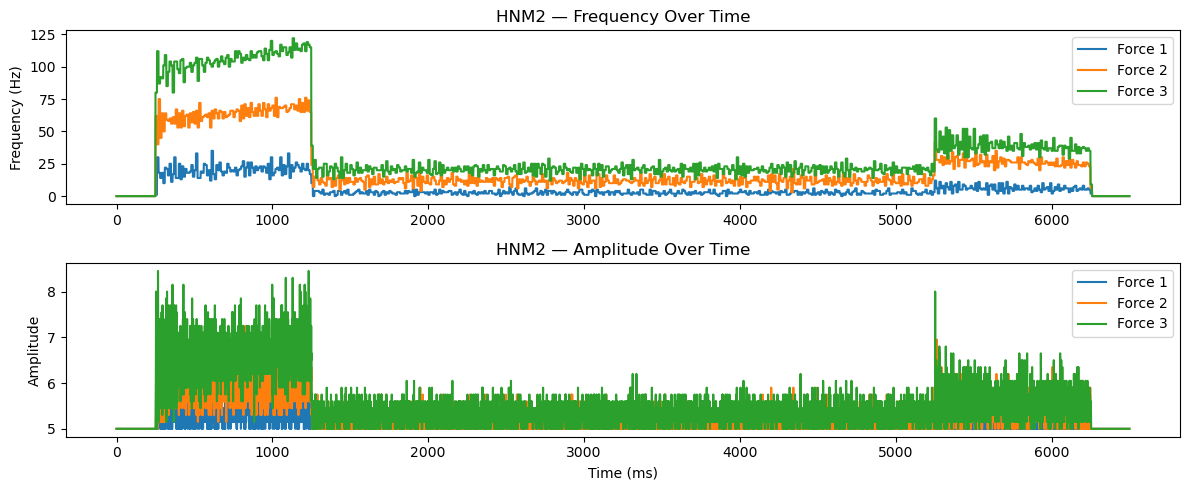

In [6]:
import matplotlib.pyplot as plt
#ANM
time = range(len(A_fnm_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1) 
plt.plot(time, F_fnm_all[0], label="Force 1")
plt.plot(time, F_fnm_all[1], label="Force 2")
plt.plot(time, F_fnm_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("FNM — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_fnm_all[0], label="Force 1")
plt.plot(time, A_fnm_all[1], label="Force 2")
plt.plot(time, A_fnm_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("FNM — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("FNM_plot.png", dpi=300)
plt.show()

#ANM
time = range(len(A_anm_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)  
plt.plot(time, F_anm_all[0], label="Force 1")
plt.plot(time, F_anm_all[1], label="Force 2")
plt.plot(time, F_anm_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("ANM — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_anm_all[0], label="Force 1")
plt.plot(time, A_anm_all[1], label="Force 2")
plt.plot(time, A_anm_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("ANM — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("ANM_plot.png", dpi=300)
plt.show()

#HNM1

time = range(len(A_hnm1_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1) 
plt.plot(time, F_hnm1_all[0], label="Force 1")
plt.plot(time, F_hnm1_all[1], label="Force 2")
plt.plot(time, F_hnm1_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("HNM1 — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_hnm1_all[0], label="Force 1")
plt.plot(time, A_hnm1_all[1], label="Force 2")
plt.plot(time, A_hnm1_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("HNM1 — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("HNM1_plot.png", dpi=300)
plt.show()

#HNM2

time = range(len(A_hnm2_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1) 
plt.plot(time, F_hnm2_all[0], label="Force 1")
plt.plot(time, F_hnm2_all[1], label="Force 2")
plt.plot(time, F_hnm2_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("HNM2 — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_hnm2_all[0], label="Force 1")
plt.plot(time, A_hnm2_all[1], label="Force 2")
plt.plot(time, A_hnm2_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("HNM2 — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("HNM2_plot.png", dpi=300)
plt.show()

In [7]:
#Q2
A_min = 5
A_max = 20
F_min = 0
F_max = 1000
R_max = 1000
stim2 = mat['Stim2']
RA2 = mat['RA_Spikes2']
SA2 = mat['SA1_Spikes2']

s_lows = []
s_highs = []
A_anm_all, F_anm_all = [], []
A_fnm_all, F_fnm_all = [], []
A_hnm1_all, F_hnm1_all = [], []
A_hnm2_all, F_hnm2_all = [], []
#amplitude encoding model:
def ANM(s, s_low, s_high):
    A = np.zeros(s.shape)
    for i in range(len(s)):
        if s[i] < s_low:
            A[i] = 0
        elif s[i] > s_high:
            A[i] = A_max
        else:
            A[i] = A_min + (A_max - A_min) * ((s[i] - s_low)/(s_high - s_low))
    #pulse freq fixed at 50Hz; call it here or outside?
    #F = 50
    return A

#frequecny encoding model:

bin_width = 10
def FNM(RA2, SA2,f, bin_width =10, F_min = 0, F_max = 1000, R_max = 1000):
    RA = RA2[:, : , f]
    SA1 = SA2[:, : ,f]
    spikes = np.vstack([RA, SA1]) # for sum of each of the 100 mechanoreceptors at each timepoint
    n , time = spikes.shape
    bins = time//bin_width
    R = np.zeros(bins)
    for b in range(bins):
        start = b * bin_width
        end = (b+1) * bin_width
        total_spikes = np.sum(spikes[:,start:end])
        R[b] = total_spikes / (n * 0.01)
    F = np.zeros_like(R)
    for i in range(len(R)):
        if R[i] <=0:
            F[i] = F_min
        elif R[i]>= R_max:
            F[i] = F_max
        else:
            F[i] = F_min + (F_max - F_min) * R[i]/R_max
    F_matrix = np.repeat(F, bin_width)[:time]

    A = (A_max - A_min) /2
    A_matrix = np.ones_like(F_matrix) * A
    return F_matrix, A_matrix

def HNM1(s,s_low, s_high, RA1, SA1, f):
    A = ANM(s, s_low, s_high)
    F, _ = FNM(RA2, SA2, f)
    return A, F

def HNM2( RA2, SA2, f, A_min = 5, A_max = 20):
    RA_f = RA2[:,:,f]
    SA1_f = SA2[:,:,f]
    spikes = np.vstack([RA_f, SA1_f])
    N_act = np.sum(spikes>0, axis =0)
    A = A_min +(A_max - A_min) * (N_act /(spikes.shape[0]))
    F, _ = FNM(RA2, SA2, f)

    return A, F

#finding s_n, s_15 and s_75:
for f in range(3):
    s = stim2[f, :]
    #print(f'force is {f}',s)
    s_max = np.max(s)
    #print(f'max = {s_max}')
    s_low = 0.15 * s_max
    s_high = 0.75 * s_max

    s_lows.append(s_low)
    s_highs.append(s_high)
    #print(f's_lows = {s_lows} , s_highs = {s_highs}')
    #anm
    A_anm = ANM(s, s_low, s_high)
    A_anm_all.append(A_anm)
    F_anm_all.append(np.ones_like(A_anm) * 50)

    #fnm
    F_fnm, A_fnm = FNM(RA2, SA2, f)
    A_fnm_all.append(A_fnm)
    F_fnm_all.append(F_fnm)

    #hnm1
    
    A_hnm1, F_hnm1 = HNM1(s, s_low, s_high, RA2, SA2, f)
    A_hnm1_all.append(A_hnm1)
    F_hnm1_all.append(F_hnm1)

    #hnm2
    A_hnm2, F_hnm2 = HNM2(RA2, SA2, f)
    A_hnm2_all.append(A_hnm2)
    F_hnm2_all.append(F_hnm2)


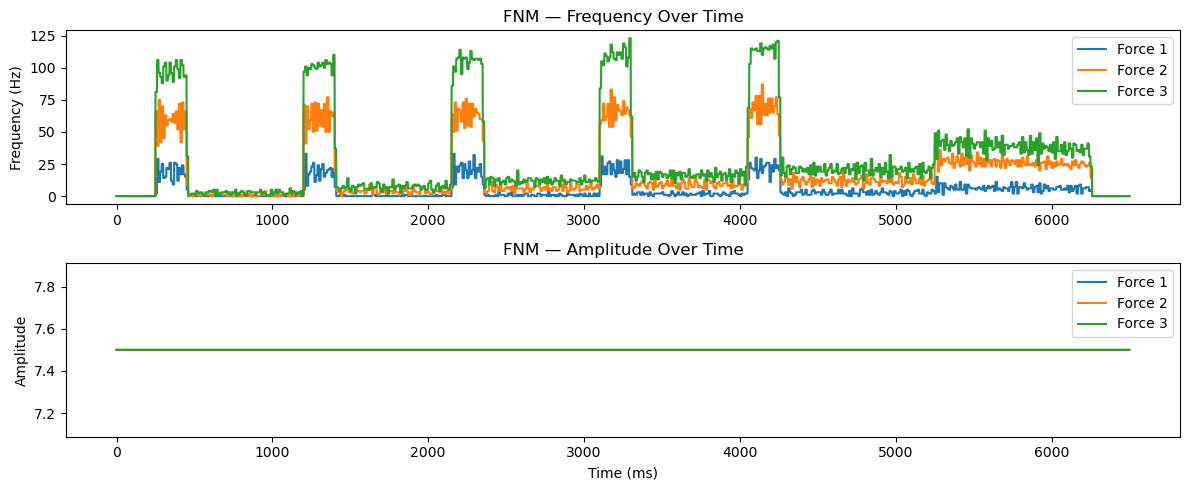

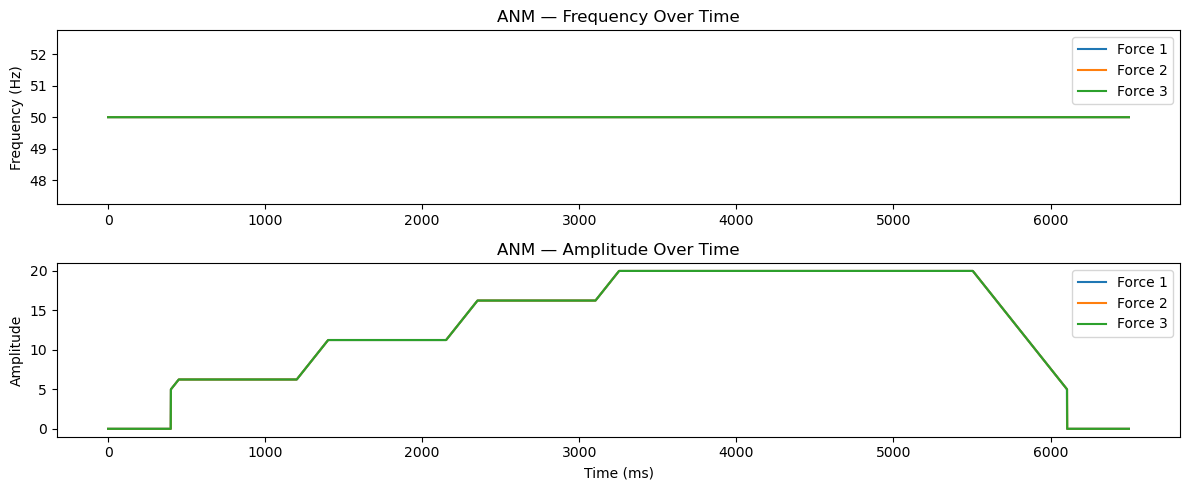

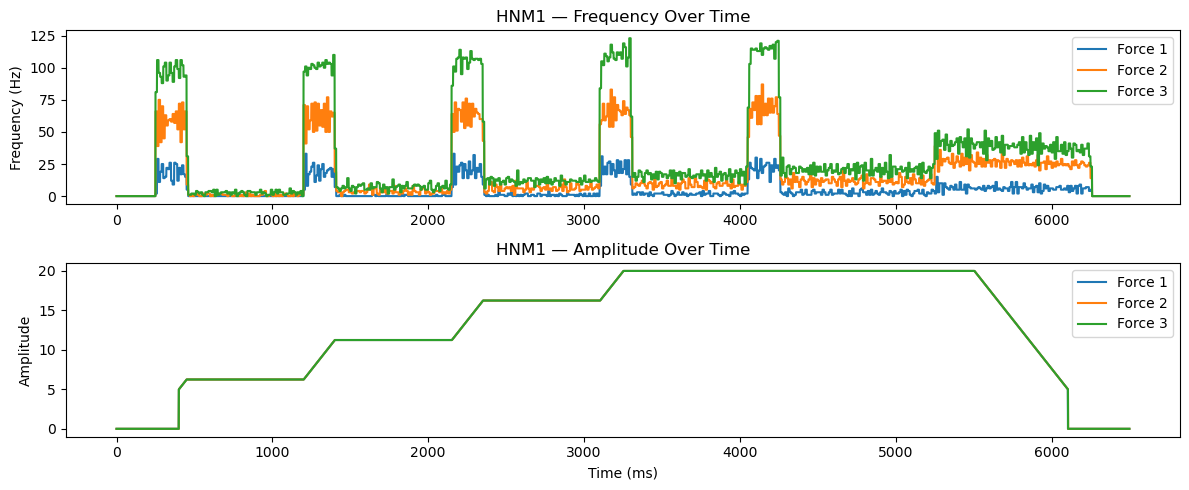

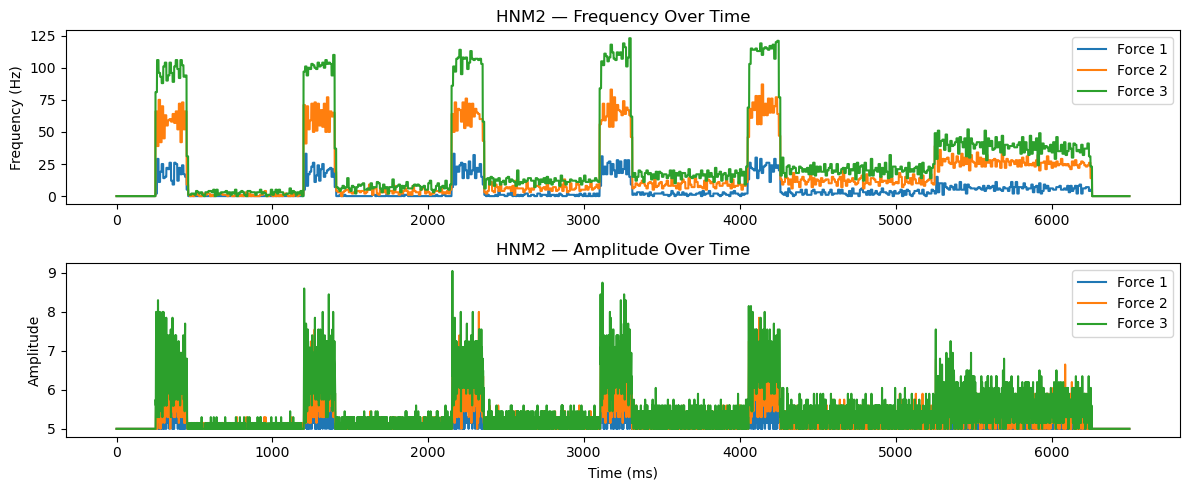

In [8]:
#ANM
time = range(len(A_fnm_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1) 
plt.plot(time, F_fnm_all[0], label="Force 1")
plt.plot(time, F_fnm_all[1], label="Force 2")
plt.plot(time, F_fnm_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("FNM — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_fnm_all[0], label="Force 1")
plt.plot(time, A_fnm_all[1], label="Force 2")
plt.plot(time, A_fnm_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("FNM — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("FNM_plot2.png", dpi=300)
plt.show()

#ANM
time = range(len(A_anm_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
plt.plot(time, F_anm_all[0], label="Force 1")
plt.plot(time, F_anm_all[1], label="Force 2")
plt.plot(time, F_anm_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("ANM — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_anm_all[0], label="Force 1")
plt.plot(time, A_anm_all[1], label="Force 2")
plt.plot(time, A_anm_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("ANM — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("ANM_plot2.png", dpi=300)
plt.show()

#HNM1

time = range(len(A_hnm1_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1) 
plt.plot(time, F_hnm1_all[0], label="Force 1")
plt.plot(time, F_hnm1_all[1], label="Force 2")
plt.plot(time, F_hnm1_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("HNM1 — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_hnm1_all[0], label="Force 1")
plt.plot(time, A_hnm1_all[1], label="Force 2")
plt.plot(time, A_hnm1_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("HNM1 — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("HNM1_plot2.png", dpi=300)
plt.show()

#HNM2

time = range(len(A_hnm2_all[0]))
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
plt.plot(time, F_hnm2_all[0], label="Force 1")
plt.plot(time, F_hnm2_all[1], label="Force 2")
plt.plot(time, F_hnm2_all[2], label="Force 3")
plt.ylabel("Frequency (Hz)")
plt.title("HNM2 — Frequency Over Time")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, A_hnm2_all[0], label="Force 1")
plt.plot(time, A_hnm2_all[1], label="Force 2")
plt.plot(time, A_hnm2_all[2], label="Force 3")
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("HNM2 — Amplitude Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("HNM2_plot2.png", dpi=300)
plt.show()

R range: 0.00 to 123.00


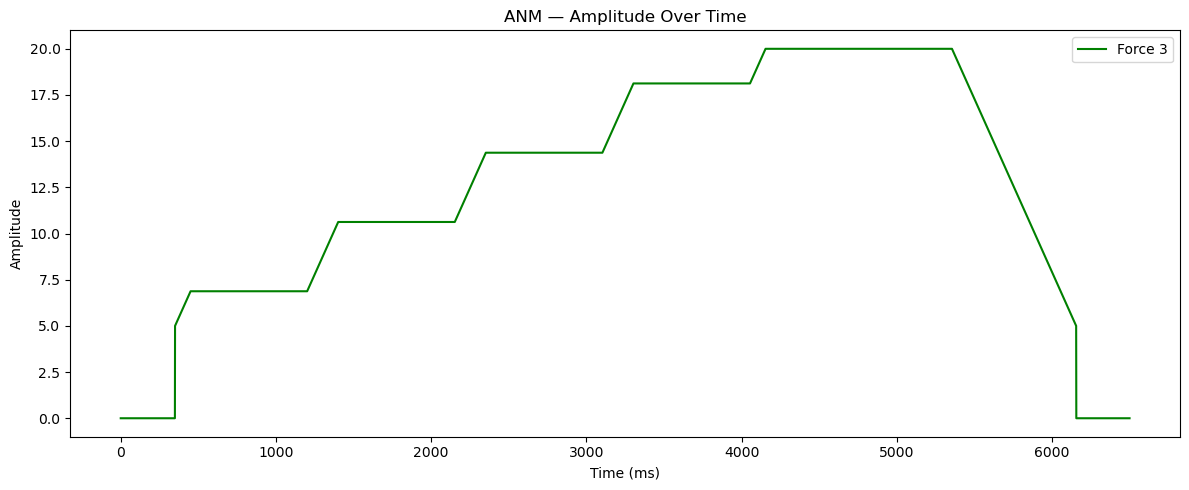

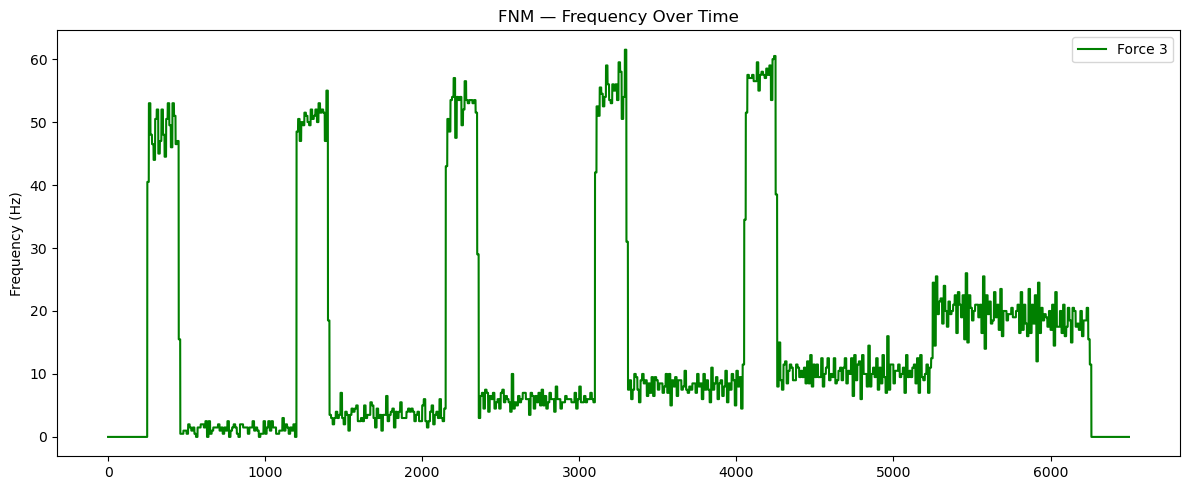

In [27]:
#Q4:(stepping stim)
##Q4, ANM (1) , FNM(1)
A_min = 5
A_max = 20
F_min = 0
F_max = 1000
R_max = 2000
stim2 = mat['Stim2']
RA2 = mat['RA_Spikes2']
SA2 = mat['SA1_Spikes2']

s_lows = []
s_highs = []
A_anm_all, F_anm_all = [], []
A_fnm_all, F_fnm_all = [], []
A_hnm1_all, F_hnm1_all = [], []
A_hnm2_all, F_hnm2_all = [], []
#amplitude encoding model:
def ANM(s, s_low, s_high):
    A = np.zeros(s.shape)
    for i in range(len(s)):
        if s[i] < s_low:
            A[i] = 0
        elif s[i] > s_high:
            A[i] = A_max
        else:
            A[i] = A_min + (A_max - A_min) * ((s[i] - s_low)/(s_high - s_low))
    #pulse freq fixed at 50Hz; call it here or outside?
    #F = 50
    return A

#frequecny encoding model:

bin_width = 10
def FNM(RA2, SA2,f, bin_width =10, F_min = 0, F_max = 1000, R_max = 2000):
    RA = RA2[:, : , f]
    SA1 = SA2[:, : ,f]
    spikes = np.vstack([RA, SA1]) # for sum of each of the 100 mechanoreceptors at each timepoint
    n , time = spikes.shape
    bins = time//bin_width
    R = np.zeros(bins)
    for b in range(bins):
        start = b * bin_width
        end = (b+1) * bin_width
        total_spikes = np.sum(spikes[:,start:end])
        R[b] = total_spikes / (n * 0.01)
    print(f"R range: {np.min(R):.2f} to {np.max(R):.2f}")
    F = np.zeros_like(R)
    for i in range(len(R)):
        if R[i] <=0:
            F[i] = F_min
        elif R[i]>= R_max:
            F[i] = F_max
        else:
            F[i] = F_min + (F_max - F_min) * R[i]/R_max
    F_matrix = np.repeat(F, bin_width)[:time]

    A = (A_max - A_min) /2
    A_matrix = np.ones_like(F_matrix) * A
    return F_matrix, A_matrix

f= 2 #only high force value is needed according to question
s = stim2[f, :]
#print(f'force is {f}',s)
s_max = np.max(s)
#print(f'max = {s_max}')
s_low = 0.10 * s_max
s_high = 0.90 * s_max

s_lows.append(s_low)
s_highs.append(s_high)
#print(f's_lows = {s_lows} , s_highs = {s_highs}')
#anm
A_anm = ANM(s, s_low, s_high)
A_anm_all.append(A_anm)
F_anm_all.append(np.ones_like(A_anm) * 50)

#fnm
F_fnm, A_fnm = FNM(RA2, SA2, f)
A_fnm_all.append(A_fnm)
F_fnm_all.append(F_fnm)

#plot both:
time = range(len(A_fnm_all[0]))



#ANM
plt.figure(figsize=(12, 5))
plt.plot(time, A_anm_all[0], label="Force 3", color = 'green')
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("ANM — Amplitude Over Time")
plt.tight_layout()
plt.savefig("ANM_plot4.1.png", dpi=300)
plt.legend()

#FNM
plt.figure(figsize=(12, 5))
plt.plot(time, F_fnm_all[0], label="Force 3", color = 'green')
plt.ylabel("Frequency (Hz)")
plt.title("FNM — Frequency Over Time")
plt.savefig("FNM_plot4.1.png", dpi=300)
plt.tight_layout()
plt.legend()

R range: 0.00 to 123.00


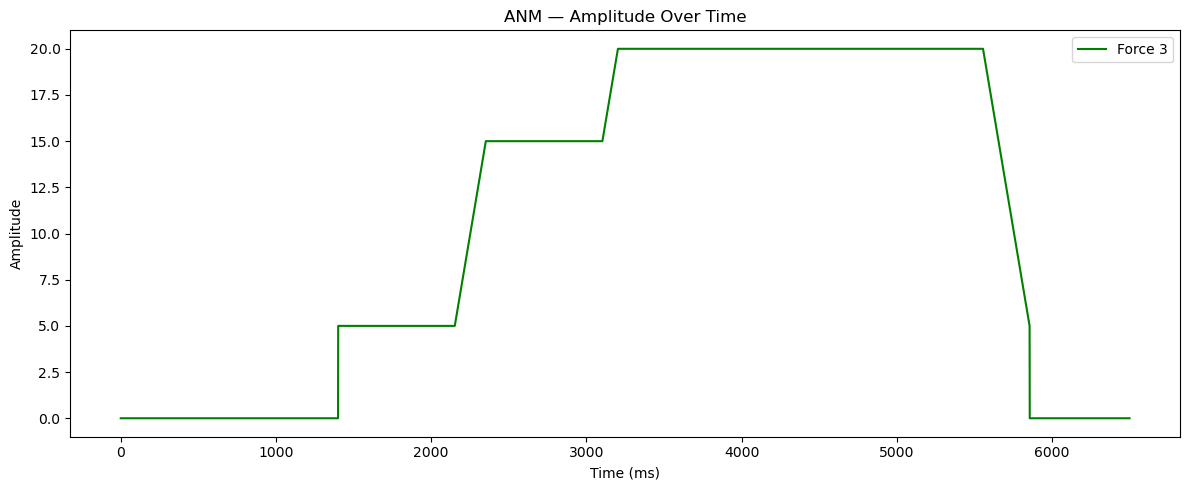

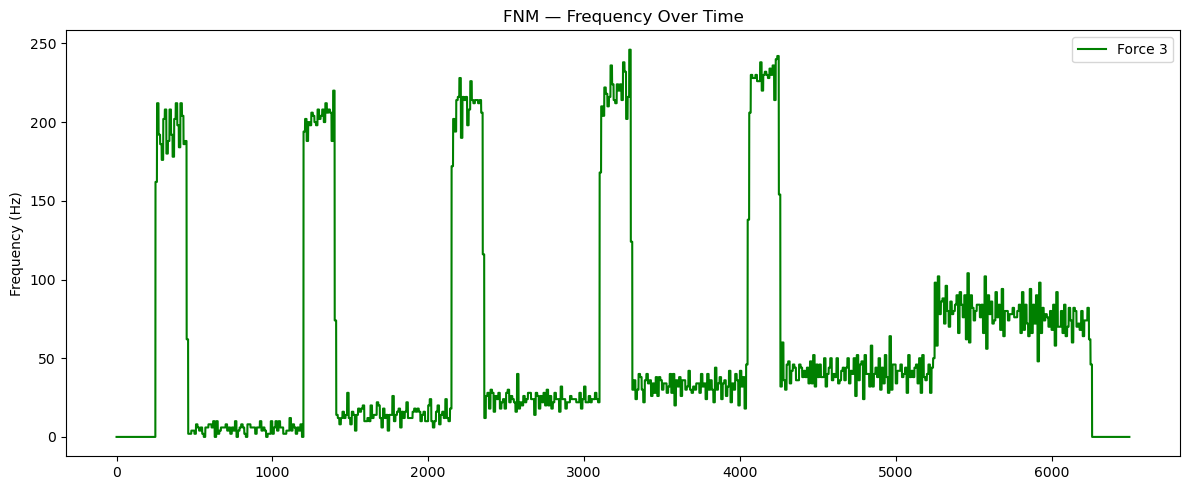

In [24]:
#Q4:(stepping stim)
##Q4, ANM (2) , FNM(2)
A_min = 5
A_max = 20
F_min = 0
F_max = 1000
R_max = 500
stim2 = mat['Stim2']
RA2 = mat['RA_Spikes2']
SA2 = mat['SA1_Spikes2']

s_lows = []
s_highs = []
A_anm_all, F_anm_all = [], []
A_fnm_all, F_fnm_all = [], []
A_hnm1_all, F_hnm1_all = [], []
A_hnm2_all, F_hnm2_all = [], []
#amplitude encoding model:
def ANM(s, s_low, s_high):
    A = np.zeros(s.shape)
    for i in range(len(s)):
        if s[i] < s_low:
            A[i] = 0
        elif s[i] > s_high:
            A[i] = A_max
        else:
            A[i] = A_min + (A_max - A_min) * ((s[i] - s_low)/(s_high - s_low))
    #pulse freq fixed at 50Hz; call it here or outside?
    #F = 50
    return A

#frequecny encoding model:

bin_width = 10
def FNM(RA2, SA2,f, bin_width =10, F_min = 0, F_max = 1000, R_max = 500):
    RA = RA2[:, : , f]
    SA1 = SA2[:, : ,f]
    spikes = np.vstack([RA, SA1]) # for sum of each of the 100 mechanoreceptors at each timepoint
    n , time = spikes.shape
    bins = time//bin_width
    R = np.zeros(bins)
    for b in range(bins):
        start = b * bin_width
        end = (b+1) * bin_width
        total_spikes = np.sum(spikes[:,start:end])
        R[b] = total_spikes / (n * 0.01)
    print(f"R range: {np.min(R):.2f} to {np.max(R):.2f}")
    F = np.zeros_like(R)
    for i in range(len(R)):
        if R[i] <=0:
            F[i] = F_min
        elif R[i]>= R_max:
            F[i] = F_max
        else:
            F[i] = F_min + (F_max - F_min) * R[i]/R_max
    F_matrix = np.repeat(F, bin_width)[:time]

    A = (A_max - A_min) /2
    A_matrix = np.ones_like(F_matrix) * A
    return F_matrix, A_matrix

f= 2 #only high force value is needed according to question
s = stim2[f, :]
#print(f'force is {f}',s)
s_max = np.max(s)
#print(f'max = {s_max}')
s_low = 0.40 * s_max
s_high = 0.70 * s_max

s_lows.append(s_low)
s_highs.append(s_high)
#print(f's_lows = {s_lows} , s_highs = {s_highs}')
#anm
A_anm = ANM(s, s_low, s_high)
A_anm_all.append(A_anm)
F_anm_all.append(np.ones_like(A_anm) * 50)

#fnm
F_fnm, A_fnm = FNM(RA2, SA2, f)
A_fnm_all.append(A_fnm)
F_fnm_all.append(F_fnm)

#plot both:
time = range(len(A_fnm_all[0]))



#ANM
plt.figure(figsize=(12, 5))
plt.plot(time, A_anm_all[0], label="Force 3", color = 'green')
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("ANM — Amplitude Over Time")
plt.tight_layout()
plt.savefig("ANM_plot4.2.png", dpi=300)
plt.legend()

#FNM
plt.figure(figsize=(12, 5))
plt.plot(time, F_fnm_all[0], label="Force 3", color = 'green')
plt.ylabel("Frequency (Hz)")
plt.title("FNM — Frequency Over Time")
plt.savefig("FNM_plot4.2.png", dpi=300)
plt.tight_layout()
plt.legend()

R range: 0.00 to 123.00


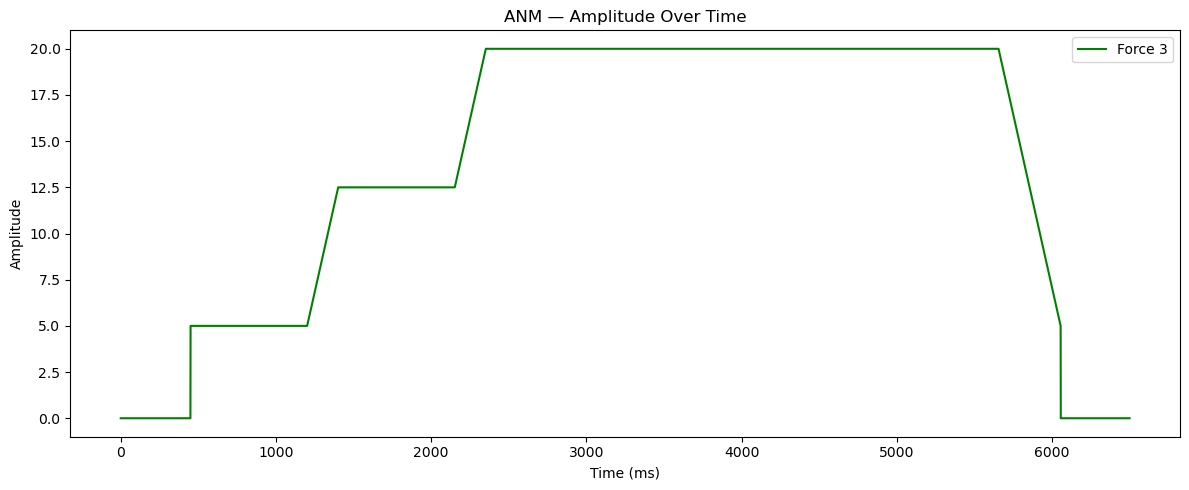

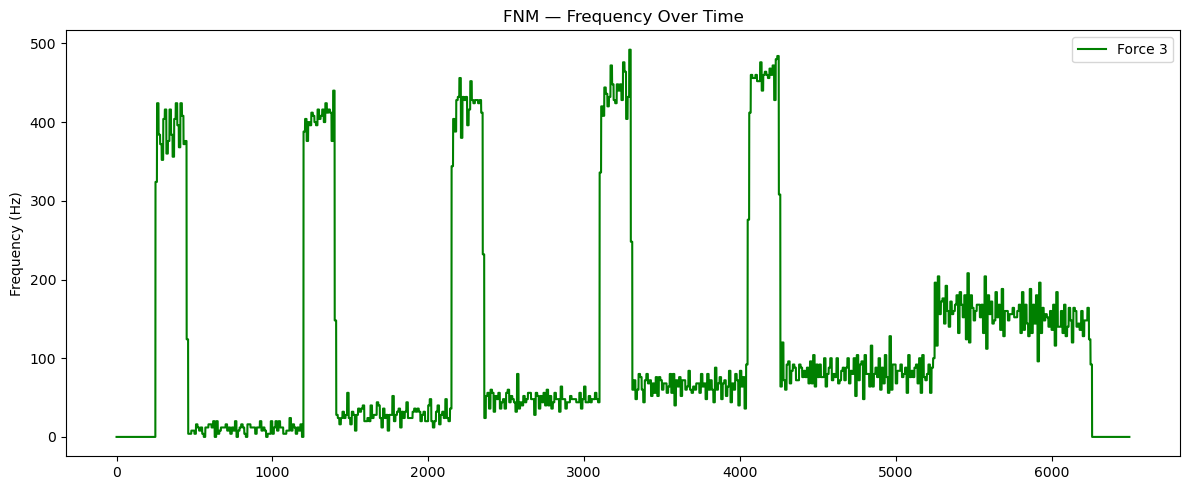

In [23]:
#Q4:(stepping stim)
##Q4, ANM (3) , FNM(3)
A_min = 5
A_max = 20
F_min = 0
F_max = 1000
R_max = 250
stim2 = mat['Stim2']
RA2 = mat['RA_Spikes2']
SA2 = mat['SA1_Spikes2']

s_lows = []
s_highs = []
A_anm_all, F_anm_all = [], []
A_fnm_all, F_fnm_all = [], []
A_hnm1_all, F_hnm1_all = [], []
A_hnm2_all, F_hnm2_all = [], []
#amplitude encoding model:
def ANM(s, s_low, s_high):
    A = np.zeros(s.shape)
    for i in range(len(s)):
        if s[i] < s_low:
            A[i] = 0
        elif s[i] > s_high:
            A[i] = A_max
        else:
            A[i] = A_min + (A_max - A_min) * ((s[i] - s_low)/(s_high - s_low))
    #pulse freq fixed at 50Hz; call it here or outside?
    #F = 50
    return A

#frequecny encoding model:

bin_width = 10
def FNM(RA2, SA2,f, bin_width =10, F_min = 0, F_max = 1000, R_max = 250):
    RA = RA2[:, : , f]
    SA1 = SA2[:, : ,f]
    spikes = np.vstack([RA, SA1]) # for sum of each of the 100 mechanoreceptors at each timepoint
    n , time = spikes.shape
    bins = time//bin_width
    R = np.zeros(bins)
    for b in range(bins):
        start = b * bin_width
        end = (b+1) * bin_width
        total_spikes = np.sum(spikes[:,start:end])
        R[b] = total_spikes / (n * 0.01)
    print(f"R range: {np.min(R):.2f} to {np.max(R):.2f}")
    F = np.zeros_like(R)
    for i in range(len(R)):
        if R[i] <=0:
            F[i] = F_min
        elif R[i]>= R_max:
            F[i] = F_max
        else:
            F[i] = F_min + (F_max - F_min) * R[i]/R_max
    F_matrix = np.repeat(F, bin_width)[:time]

    A = (A_max - A_min) /2
    A_matrix = np.ones_like(F_matrix) * A
    return F_matrix, A_matrix

f= 2 #only high force value is needed according to question
s = stim2[f, :]
#print(f'force is {f}',s)
s_max = np.max(s)
#print(f'max = {s_max}')
s_low = 0.20 * s_max
s_high = 0.60 * s_max

s_lows.append(s_low)
s_highs.append(s_high)
#print(f's_lows = {s_lows} , s_highs = {s_highs}')
#anm
A_anm = ANM(s, s_low, s_high)
A_anm_all.append(A_anm)
F_anm_all.append(np.ones_like(A_anm) * 50)

#fnm
F_fnm, A_fnm = FNM(RA2, SA2, f)
A_fnm_all.append(A_fnm)
F_fnm_all.append(F_fnm)

#plot both:
time = range(len(A_fnm_all[0]))



#ANM
plt.figure(figsize=(12, 5))
plt.plot(time, A_anm_all[0], label="Force 3", color = 'green')
plt.ylabel("Amplitude")
plt.xlabel("Time (ms)")
plt.title("ANM — Amplitude Over Time")
plt.tight_layout()
plt.savefig("ANM_plot4.3.png", dpi=300)
plt.legend()

#FNM
plt.figure(figsize=(12, 5))
plt.plot(time, F_fnm_all[0], label="Force 3", color = 'green')
plt.ylabel("Frequency (Hz)")
plt.title("FNM — Frequency Over Time")
plt.savefig("FNM_plot4.3.png", dpi=300)
plt.tight_layout()
plt.legend()

In [ ]:
#Q6 (with stepping stimuli):
A = A_anm_all[1] 
F = F_anm_all[1]
time = np.arange(len(A)) 

times = [] 
amps = []
next_time = 0

for t in range(len(F)):
    if t >= next_time:
        times.append(t)
        amps.append(A[t])
        if F[t] > 0:
            next_time = t + int(1000 / F[t])
plt.figure(figsize=(8, 2))
plt.vlines(times, ymin=0, ymax=amps, color='pink', linewidth=2)

plt.ylim(0, 25)
plt.xlim(0, 6500)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("ANM Encoding – Force Level 2")
plt.tight_layout()
plt.savefig("ANM_plot6.png", dpi=300)
plt.show()

In [ ]:
A = A_fnm_all[1] 
F = F_fnm_all[1]
time = np.arange(len(A)) 

times = [] 
amps = []
next_time = 0

for t in range(len(F)):
    if t >= next_time:
        times.append(t)
        amps.append(A[t])
        if F[t] > 0:
            next_time = t + int(1000 / F[t])
plt.figure(figsize=(8, 2))
plt.vlines(times, ymin=0, ymax=amps, color='tan', linewidth=2)

plt.ylim(0, 25)
plt.xlim(0, 6500)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("FNM Encoding – Force Level 2")
plt.tight_layout()
plt.savefig("FNM_plot6.png", dpi=300)
plt.show()

In [ ]:
A = A_hnm1_all[1] 
F = F_hnm1_all[1]
time = np.arange(len(A)) 

times = [] 
amps = []
next_time = 0

for t in range(len(F)):
    if t >= next_time:
        times.append(t)
        amps.append(A[t])
        if F[t] > 0:
            next_time = t + int(1000 / F[t])
plt.figure(figsize=(8, 2))
plt.vlines(times, ymin=0, ymax=amps, color='steelblue', linewidth=2)

plt.ylim(0, 25)
plt.xlim(0, 6500)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("HNM1 Encoding – Force Level 2")
plt.tight_layout()
plt.savefig("HNM1_plot6.png", dpi=300)
plt.show()

In [ ]:
A = A_hnm2_all[1] 
F = F_hnm2_all[1]
time = np.arange(len(A)) 

times = [] 
amps = []
next_time = 0

for t in range(len(F)):
    if t >= next_time:
        times.append(t)
        amps.append(A[t])
        if F[t] > 0:
            next_time = t + int(1000 / F[t])
plt.figure(figsize=(8, 2))
plt.vlines(times, ymin=0, ymax=amps, color='teal', linewidth=2)

plt.ylim(0, 25)
plt.xlim(0, 6500)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("HNM2 Encoding – Force Level 2")
plt.tight_layout()
plt.savefig("HNM2_plot6.png", dpi=300)
plt.show()